<a href="https://colab.research.google.com/github/u9828057/Python_Practice/blob/main/Electronics_with_Python/Day24_08_17_MOSFET_%E8%87%A8%E7%95%8C%E9%BB%9E%E8%A6%96%E8%A6%BA%E5%8C%96.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--------(Electronics_Simulation: MOSFET 臨界點視覺化)--------

圖片儲存成功!


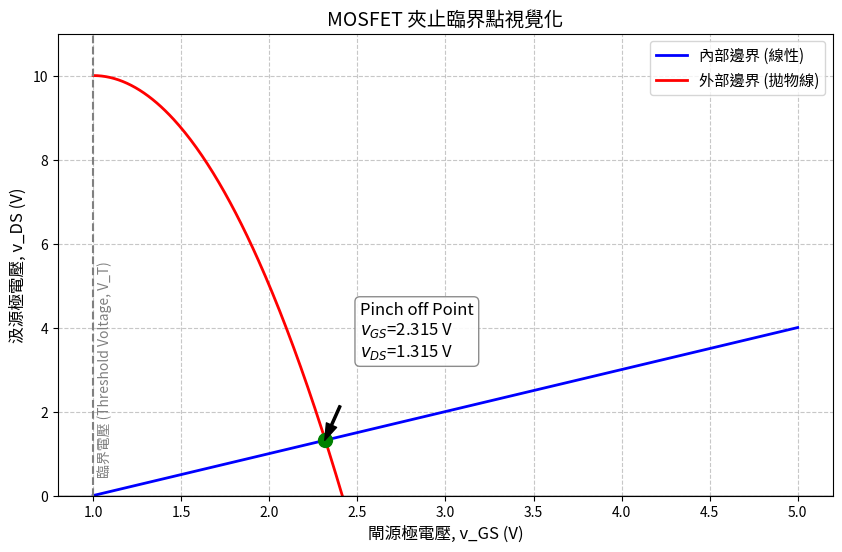

In [68]:
import numpy as np
import matplotlib.pyplot as plt
print("--------(Electronics_Simulation: MOSFET 臨界點視覺化)--------\n")

#======================================================================
# 4.3.3. 輸入輸出電壓特性 Input-output voltage characteristics
#======================================================================

# ◇1. 設定電路參數 (這組參數會產生約 2.317V 的臨界點)
V_DD = 10.0  #汲極電源電壓 (V)
V_T = 1.0   #臨界電壓: Threshold Voltage (V)
K = 2e-3    #導電參數 (A/V**2)，也就是 2 mA/V**2
R_D = 5e3   #汲極電阻 (Ohm)，也就是 5 kOhm

#-------------------------------------------------------------

# ◇2. 建立輸入電壓陣列

# 產生一個從 V_T 到 5.0V 的連續陣列，共 500 的量測點
v_GS = np.linspace(V_T, 5.0, 500)

#-------------------------------------------------------------

# ◇3. 計算兩條曲線的 v_DS

# 曲線一: 內部物理邊界 (剛好夾止的瞬間，為一條直線)
v_DS_internal = v_GS - V_T  #Vov(過載電壓: Overdrive Voltage)

# 曲線二: 外部電路限制 (負載線 KVL 帶入飽和區電流公式，為一條拋物線)
# 步驟 A: 先計算 MOSFET 在飽和區的汲極電流 I_D
I_D = K * 0.5 * (v_GS - V_T)**2

# 步驟 B: 帶入外部電路 KVL 迴路公式
v_DS_external = V_DD - I_D*R_D


#-------------------------------------
# 補充資料: 尋找飽和區工作區邊界
#-------------------------------------
# §臨界條件: v_DS = v_GS - V_T   (夾止點 Pinch-off)
# §電路限制: v_DS = VDD - I_D*R_D  (KVL)
# 當 v_GS 增加至 v_DS = v_GS - V_T 時，會從飽和區 (Saturation) 進入三極體區 (Triode)

# 因此尋找「為了維持在飽和區，v_GS最大能到多少」的工作區邊界為:
# v_DS = V_DD - I_D*R_D = v_GS-V_T

#-------------------------------------------------------------

# ◇4. 尋找交點 (模擬聯立方程式求解)

# 尋找兩條線 Y 值最接近 (差值絕對值最小) 的那個索引
# 也就是「尋找內部物理邊界與外部 KVL 負載線的交界點」
difference = np.abs(v_DS_internal - v_DS_external)

# 找出這 500 個量測點之中，差距最小的點在「第幾個位置」
intersection_index = np.argmin(difference)


#------------------------------
# §補充技巧: np.argmin()
#------------------------------
# np.argmin() 的作用是：「取得最小值『在哪裡（Index，索引位置）』」
# 可以把這個函數拆解來看：
# min：代表 Minimum（最小值）
# arg：在數學上代表 Argument（引數/自變數），在陣列操作中，它指的就是位置（Index）

# 假設算出來的 intersection_index 為 312
# 可以利用這個索引位置，回到原本的陣列抓取真正的電壓值
# v_GS_q = v_GS[312]
# v_DS_q = v_DS_internal[312]

#-------------------------------------------------------------

# ◇5. 數據視覺化 (繪製圖表)
plt.figure(figsize=(10, 6))

# 畫出兩條線
plt.plot(v_GS,v_DS_internal, label="內部邊界 (線性)", color="blue", linewidth=2)
plt.plot(v_GS,v_DS_external, label="外部邊界 (拋物線)", color="red", linewidth=2)

# 標示出交點 (臨界點)
plt.plot(v_GS_q, v_DS_q, "go", markersize=10)  #綠色大圓點
plt.annotate(
    # 第一部分: 要顯示的文字內容
f"Pinch off Point\n$v_{{GS}}$={v_GS_q:.3f} V\n$v_{{DS}}$={v_DS_q:.3f} V",

    # 第二部分: 箭頭要指在哪裡?
    xy=(v_GS_q, v_DS_q),

    # 第三部分: 文字框要放在哪裡?
    xytext=(v_GS_q + 0.2, v_DS_q + 2.0),

    # 第四部份: 箭頭的長相
    arrowprops=dict(facecolor="black",shrink=0.5,width=1.5,headwidth=8),

    # 第五部分: 文字的大小與外框長相
    fontsize=12,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.9)
)

# 設定圖表格式
plt.title("MOSFET 夾止臨界點視覺化", fontsize=14, fontweight="bold")
plt.xlabel("閘源極電壓, v_GS (V)", fontsize=12)
plt.ylabel("汲源極電壓, v_DS (V)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.7)
plt.legend(fontsize=11)


# §補充資料: fontweight=""
# fontweight="bold": 讓標題變成粗體 (fontweight：指的是字體的粗細程度（字重），bold：意思是「粗體」)
# 除了 'bold' 之外，fontweight 通常還可以設定為其他數值或英文，
# 例如 'normal'（一般粗細）、'light'（細體），或是用數字 100 到 900 來表示不同的粗細程度


# 劃出坐標軸基準線
plt.axhline(0, color="black", linewidth=1)
plt.axvline(V_T, color="gray", linewidth=1.5, linestyle="--")
plt.text(
    V_T + 0.02, 0.5, "臨界電壓 (Threshold Voltage, V_T)",
    rotation=90, color="gray"
    )

# 限制 Y 軸顯示範圍以便觀察
plt.ylim(0, V_DD + 1)

# 儲存與顯示圖表

# 將畫好的圖存成高畫質 PNG 檔
plt.savefig("MOSFET_臨界點視覺化", dpi=300, bbox_inches="tight")
print(f"圖片儲存成功!")

# 最後顯示圖片
plt.show()


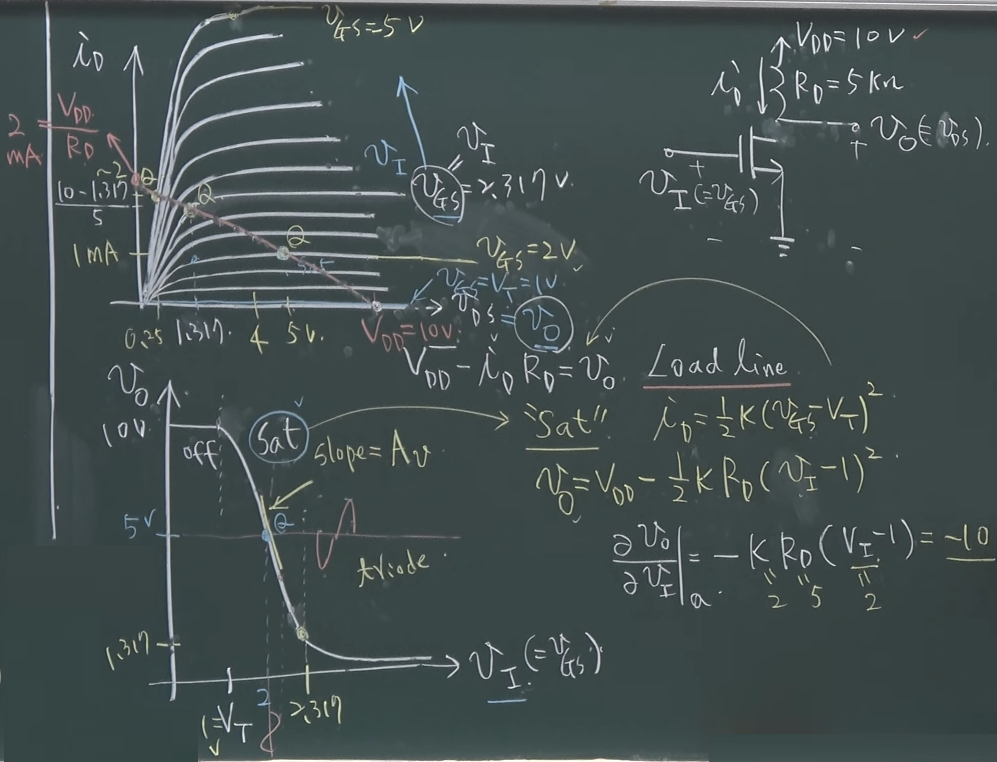

In [20]:
#=========================================
# --- Colab 畫圖中文顯示起手式 ---
#=========================================
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 下載微軟正黑體 (或是 Noto 繁體中文)
!wget -q -O NotoSansTC-Regular.otf \
https://github.com/googlefonts/noto-cjk/raw/main/Sans/OTF/TraditionalChinese/NotoSansCJKtc-Regular.otf
fm.fontManager.addfont('NotoSansTC-Regular.otf')
plt.rc('font', family='Noto Sans CJK TC')
plt.rcParams['axes.unicode_minus'] = False
# --------------------------------

print("環境設定完成！可以開始畫圖了！")

環境設定完成！可以開始畫圖了！
